# Patzelt--Bouchaud aggregate-impact scaling in BTCUSDT

This notebook provides an adapted replication of the main empirical artifacts in Patzelt and Bouchaud
(2018), *Universal scaling and nonlinearity of aggregate price impact in
financial markets*, for continuously traded Binance BTCUSDT data. It asks:

1. whether aggregate-volume response curves at different event counts collapse
   after scale-specific horizontal and vertical rescaling;
2. whether the scale exponents agree with block-sum Hurst exponents;
3. whether extreme order-sign or within-window volume imbalance is associated
   with price pinning; and
4. whether conditioning on activity reconciles any pinning result with the
   high-activity, high-volume-imbalance tail found in the main analysis.

The replication uses consecutive non-overlapping event blocks, matching the main
analysis in this project. Unlike the equity and futures samples in P&B, blocks are
not reset at UTC midnight because BTCUSDT trades continuously. Calendar dates are
retained only as descriptive labels.

The primary imbalance measure uses the paper's strictly backward-looking trailing
24-hour volume denominator. P&B instead adjust volume using realized calendar-day
volume before fitting an event-count-dependent scale to each response curve. Raw BTC
and the P&B calendar-day adjustment are retained as sensitivity specifications.

In [48]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import least_squares
from scipy.stats import linregress, theilslopes
%matplotlib inline

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
if not (PROJECT_DIR / 'src' / 'crypto_impact').exists():
    candidate = Path('/Users/petermillington/Research/market-impact-research/crypto-impact-study')
    if candidate.exists():
        PROJECT_DIR = candidate
if not (PROJECT_DIR / 'src' / 'crypto_impact').exists():
    raise FileNotFoundError('Run from the crypto-impact-study project or its notebooks directory.')
sys.path.insert(0, str(PROJECT_DIR / 'src'))

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.6f}'.format

In [49]:
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'BTCUSDT_monthly'
OUTPUT_ROOT = Path(os.environ.get(
    'CRYPTO_IMPACT_PB_OUTPUT_ROOT', PROJECT_DIR / 'reports'
))
FIGURE_DIR = OUTPUT_ROOT / 'figures'
TABLE_DIR = OUTPUT_ROOT / 'tables'
CACHE_DIR = Path(os.environ.get(
    'CRYPTO_IMPACT_PB_CACHE_DIR',
    PROJECT_DIR / 'data' / 'processed' / 'pb_scaling_cache',
))
for directory in (FIGURE_DIR, TABLE_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

N_VALUES = tuple(int(value) for value in os.environ.get(
    'CRYPTO_IMPACT_PB_N_VALUES',
    '100,250,500,1000,2000,4000,8000,16000',
).split(','))
N_BINS = int(os.environ.get('CRYPTO_IMPACT_PB_BINS', '60'))
PINNING_BINS = int(os.environ.get('CRYPTO_IMPACT_PB_PINNING_BINS', '30'))
MIN_BIN_OBS = int(os.environ.get('CRYPTO_IMPACT_PB_MIN_BIN_OBS', '100'))
TRAILING_VOLUME_WINDOW = os.environ.get('CRYPTO_IMPACT_PB_VOLUME_WINDOW', '1D')
TRAILING_VOLUME_REQUIRE_FULL_WINDOW = os.environ.get(
    'CRYPTO_IMPACT_PB_REQUIRE_FULL_VOLUME_WINDOW', '1'
) == '1'
MERGE_SAME_TIMESTAMP_SIGN = os.environ.get('CRYPTO_IMPACT_PB_MERGE', '1') == '1'
REBUILD_CACHE = os.environ.get('CRYPTO_IMPACT_PB_REBUILD_CACHE', '0') == '1'
MAX_FILES_RAW = int(os.environ.get('CRYPTO_IMPACT_MAX_FILES', '0'))
MAX_ROWS_PER_FILE_RAW = int(os.environ.get('CRYPTO_IMPACT_MAX_ROWS_PER_FILE', '0'))
MAX_FILES = MAX_FILES_RAW or None
MAX_ROWS_PER_FILE = MAX_ROWS_PER_FILE_RAW or None

files = sorted(DATA_DIR.glob('BTCUSDT-trades-*.parquet'))
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No monthly parquet files found in {DATA_DIR}')

CACHE_VERSION = 'v2_continuous'
row_limit_tag = MAX_ROWS_PER_FILE or 'all'
cache_tag = (
    f'{CACHE_VERSION}_{len(files)}files_{files[0].stem}_{files[-1].stem}_'
    f'merge{int(MERGE_SAME_TIMESTAMP_SIGN)}_rows{row_limit_tag}'
)
print(f'Files: {len(files)} ({files[0].name} to {files[-1].name})')
print(f'Event counts: {N_VALUES}')
print(f'Merge same timestamp and sign: {MERGE_SAME_TIMESTAMP_SIGN}')
print('Block construction: continuous, non-overlapping event blocks')
print(
    f'Primary volume metric: signed block volume / trailing {TRAILING_VOLUME_WINDOW} volume '
    '(current block excluded; full elapsed lookback required)'
)
print(f'Cache tag: {cache_tag}')

Files: 17 (BTCUSDT-trades-2025-01.parquet to BTCUSDT-trades-2026-05.parquet)
Event counts: (100, 250, 500, 1000, 2000, 4000, 8000, 16000)
Merge same timestamp and sign: True
Block construction: continuous, non-overlapping event blocks
Primary volume metric: signed block volume / trailing 1D volume (current block excluded; full elapsed lookback required)
Cache tag: v2_continuous_17files_BTCUSDT-trades-2025-01_BTCUSDT-trades-2026-05_merge1_rowsall


## P&B window construction

P&B form windows containing (N) successive transactions and require them to lie
within a trading day. Their same-day restriction prevents an equity or futures
window from crossing a market close. This adapted replication uses consecutive,
non-overlapping event blocks to match the main analysis, but does not reset them
at UTC midnight: midnight is not an economic boundary in continuously traded
BTCUSDT. The notebook does not rely on an interpretation of whether P&B's own
within-day windows overlap.

Transaction fills with the same millisecond timestamp and aggressor sign are
merged by default, following their treatment when exchange trade identifiers are
unavailable.

For each block the notebook records raw signed BTC volume (Q_N), order-sign sum
(E_N), within-block trade imbalance (Q_N/V_N), transaction-price return,
event intensity, and the fraction of adjacent transaction prices that change.
P&B use the quote midpoint immediately before each trade. The available
`mid_est` field equals transaction price, so the return and price-change measures
below are transaction-price proxies. This limitation is most important for the
pinning statistic and much less important at larger (N).

The primary aggregate-volume conditioning variable is signed block volume
divided by gross market volume in the trailing 24 hours. As in the main analysis,
blocks are indexed by their end time, the rolling window is closed on the left,
and the current block is excluded. A complete elapsed 24-hour history is required
at every event-count scale; a fixed minimum number of prior blocks would impose
different clock-time warm-ups as (N) changes. Raw BTC volume and P&B's
full-calendar-day adjustment are retained as robustness variables.

In [50]:
RAW_COLUMNS = ['price', 'qty', 'time', 'is_buyer_maker']
MILLISECONDS_PER_DAY = 86_400_000


def merge_timestamp_sign_events(time_ms, price, quantity, sign):
    if len(time_ms) == 0 or not MERGE_SAME_TIMESTAMP_SIGN:
        return time_ms, price, quantity, sign
    start = np.r_[
        True,
        (time_ms[1:] != time_ms[:-1]) | (sign[1:] != sign[:-1]),
    ]
    starts = np.flatnonzero(start)
    ends = np.r_[starts[1:], len(time_ms)]
    merged_quantity = np.add.reduceat(quantity, starts)
    # The last transaction price is the observable price after the merged event.
    merged_price = price[ends - 1]
    return time_ms[starts], merged_price, merged_quantity, sign[starts]


def aggregate_complete_blocks(time_ms, price, quantity, sign, n):
    complete = (len(time_ms) // n) * n
    if complete < n:
        return None
    time_matrix = time_ms[:complete].reshape(-1, n)
    price_matrix = price[:complete].reshape(-1, n)
    quantity_matrix = quantity[:complete].reshape(-1, n)
    sign_matrix = sign[:complete].reshape(-1, n)
    signed_quantity = quantity_matrix * sign_matrix
    gross_volume = quantity_matrix.sum(axis=1)
    signed_volume = signed_quantity.sum(axis=1)
    sign_sum = sign_matrix.sum(axis=1)
    duration_seconds = (time_matrix[:, -1] - time_matrix[:, 0]) / 1_000.0
    block_return = np.log(price_matrix[:, -1] / price_matrix[:, 0])
    if n > 1:
        price_change_fraction = (
            np.diff(price_matrix, axis=1) != 0
        ).mean(axis=1)
    else:
        price_change_fraction = np.full(len(price_matrix), np.nan)
    start_day_code = time_matrix[:, 0] // MILLISECONDS_PER_DAY
    end_day_code = time_matrix[:, -1] // MILLISECONDS_PER_DAY
    return pd.DataFrame({
        # Dates describe blocks; they do not determine block membership.
        'utc_day_code': start_day_code,
        'end_utc_day_code': end_day_code,
        'crosses_utc_day': start_day_code != end_day_code,
        'n_events': n,
        'start_time_ms': time_matrix[:, 0],
        'end_time_ms': time_matrix[:, -1],
        'duration_seconds': duration_seconds,
        'gross_volume_btc': gross_volume,
        'signed_volume_btc': signed_volume,
        'sign_sum': sign_sum,
        'sign_bias': sign_sum / n,
        'trade_imbalance': signed_volume / gross_volume,
        'log_return': block_return,
        'price_change_fraction': price_change_fraction,
        'endpoint_price_changed': price_matrix[:, -1] != price_matrix[:, 0],
    })


def build_pb_blocks(paths, n_values):
    frames = {n: [] for n in n_values}
    empty_carry = lambda: (
        np.empty(0, dtype=np.int64), np.empty(0, dtype=float),
        np.empty(0, dtype=float), np.empty(0, dtype=np.int8),
    )
    carries = {n: empty_carry() for n in n_values}
    daily_rows = []
    merged_daily_rows = []
    previous_final_time = None
    for file_number, path in enumerate(paths, start=1):
        raw = pd.read_parquet(path, columns=RAW_COLUMNS)
        if MAX_ROWS_PER_FILE is not None:
            raw = raw.iloc[:MAX_ROWS_PER_FILE].copy()
        raw = raw.sort_values('time', kind='stable')
        time_ms = raw['time'].to_numpy(dtype=np.int64)
        price = raw['price'].to_numpy(dtype=float)
        quantity = raw['qty'].to_numpy(dtype=float)
        sign = np.where(
            raw['is_buyer_maker'].to_numpy(dtype=bool), -1, 1
        ).astype(np.int8)
        if len(time_ms) == 0:
            continue
        if previous_final_time is not None and time_ms[0] < previous_final_time:
            raise ValueError(f'Input files are not globally ordered at {path.name}')
        previous_final_time = int(time_ms[-1])
        raw_days = time_ms // MILLISECONDS_PER_DAY
        daily_chunk = pd.DataFrame({
            'utc_day_code': raw_days, 'quantity': quantity,
        }).groupby('utc_day_code', observed=True).agg(
            raw_fills=('quantity', 'size'),
            daily_gross_volume_btc=('quantity', 'sum'),
        ).reset_index()
        daily_rows.append(daily_chunk)

        event_time, event_price, event_quantity, event_sign = merge_timestamp_sign_events(
            time_ms, price, quantity, sign
        )
        merged_daily_rows.append(pd.DataFrame({
            'utc_day_code': event_time // MILLISECONDS_PER_DAY,
        }).groupby('utc_day_code', observed=True).size().rename(
            'merged_events'
        ).reset_index())

        for n in n_values:
            carry_time, carry_price, carry_quantity, carry_sign = carries[n]
            block_time = np.concatenate((carry_time, event_time))
            block_price = np.concatenate((carry_price, event_price))
            block_quantity = np.concatenate((carry_quantity, event_quantity))
            block_sign = np.concatenate((carry_sign, event_sign))
            complete = (len(block_time) // n) * n
            if complete:
                frames[n].append(aggregate_complete_blocks(
                    block_time[:complete], block_price[:complete],
                    block_quantity[:complete], block_sign[:complete], n,
                ))
            carries[n] = (
                block_time[complete:].copy(), block_price[complete:].copy(),
                block_quantity[complete:].copy(), block_sign[complete:].copy(),
            )
        print(f'Processed {file_number:>2}/{len(paths)}: {path.name}')
    daily = pd.concat(daily_rows, ignore_index=True).groupby(
        'utc_day_code', observed=True, as_index=False
    ).agg(raw_fills=('raw_fills', 'sum'),
          daily_gross_volume_btc=('daily_gross_volume_btc', 'sum'))
    merged_daily = pd.concat(merged_daily_rows, ignore_index=True).groupby(
        'utc_day_code', observed=True, as_index=False
    )['merged_events'].sum()
    daily = daily.merge(merged_daily, on='utc_day_code', how='left')
    mean_daily_volume = daily['daily_gross_volume_btc'].mean()
    outputs = {}
    for n, parts in frames.items():
        data = pd.concat(parts, ignore_index=True)
        data = data.merge(
            daily[['utc_day_code', 'daily_gross_volume_btc']],
            on='utc_day_code', how='left', validate='many_to_one',
        )
        # Retain P&B's calendar-day volume adjustment as a robustness variable.
        data['pb_daily_adjusted_signed_volume'] = (
            data['signed_volume_btc'] * mean_daily_volume
            / data['daily_gross_volume_btc']
        )
        data['event_intensity'] = np.where(
            data['duration_seconds'] > 0,
            n / data['duration_seconds'], np.nan,
        )
        data['utc_day'] = pd.to_datetime(
            data['utc_day_code'], unit='D', utc=True
        )
        outputs[n] = data.replace([np.inf, -np.inf], np.nan)
    return outputs, daily


In [51]:
cache_paths = {n: CACHE_DIR / f'{cache_tag}_N{n}.parquet' for n in N_VALUES}
daily_cache = CACHE_DIR / f'{cache_tag}_daily.csv'
if not REBUILD_CACHE and daily_cache.exists() and all(path.exists() for path in cache_paths.values()):
    blocks_by_n = {n: pd.read_parquet(path) for n, path in cache_paths.items()}
    daily_summary = pd.read_csv(daily_cache)
    print('Loaded cached P&B block samples.')
else:
    blocks_by_n, daily_summary = build_pb_blocks(files, N_VALUES)
    for n, data in blocks_by_n.items():
        data.to_parquet(cache_paths[n], index=False)
    daily_summary.to_csv(daily_cache, index=False)
    print('Built and cached P&B block samples.')


def add_trailing_volume_normalisation(data):
    result = data.sort_values('end_time_ms', kind='stable').copy()
    end_time = pd.to_datetime(result['end_time_ms'], unit='ms', utc=True)
    gross_volume = pd.Series(
        result['gross_volume_btc'].to_numpy(dtype=float),
        index=pd.DatetimeIndex(end_time),
    )
    trailing_volume = gross_volume.rolling(
        TRAILING_VOLUME_WINDOW, closed='left', min_periods=1,
    ).sum()
    if TRAILING_VOLUME_REQUIRE_FULL_WINDOW:
        # A fixed number of prior event blocks is not scale-invariant: 100
        # N=16,000 blocks span far longer than 100 N=100 blocks. Require
        # elapsed clock time instead, so every N uses a complete lookback.
        full_window_at = end_time.min() + pd.Timedelta(TRAILING_VOLUME_WINDOW)
        trailing_volume.loc[(end_time < full_window_at).to_numpy()] = np.nan
    result['trailing_24h_volume_btc'] = trailing_volume.to_numpy()
    result['trailing_24h_signed_volume_fraction'] = (
        result['signed_volume_btc'] / result['trailing_24h_volume_btc']
    )
    # Downstream fitting code uses this explicit primary-analysis alias.
    result['pb_signed_volume'] = result['trailing_24h_signed_volume_fraction']
    return result.replace([np.inf, -np.inf], np.nan)


blocks_by_n = {
    n: add_trailing_volume_normalisation(data)
    for n, data in blocks_by_n.items()
}

sample_summary = pd.DataFrame([
    {
        'n_events': n,
        'blocks': len(data),
        'utc_days': data['utc_day_code'].nunique(),
        'blocks_crossing_utc_midnight': data['crosses_utc_day'].sum(),
        'fraction_crossing_utc_midnight': data['crosses_utc_day'].mean(),
        'median_duration_seconds': data['duration_seconds'].median(),
        'median_event_intensity': data['event_intensity'].median(),
        'valid_trailing_volume_blocks': data['pb_signed_volume'].notna().sum(),
        'median_trailing_24h_volume_btc': data['trailing_24h_volume_btc'].median(),
        'median_abs_trailing_volume_fraction': data['pb_signed_volume'].abs().median(),
        'median_abs_sign_bias': data['sign_bias'].abs().median(),
        'median_abs_trade_imbalance': data['trade_imbalance'].abs().median(),
    }
    for n, data in blocks_by_n.items()
])
display(sample_summary)

Loaded cached P&B block samples.


,n_events,blocks,utc_days,blocks_crossing_utc_midnight,fraction_crossing_utc_midnight,median_duration_seconds,median_event_intensity,valid_trailing_volume_blocks,median_trailing_24h_volume_btc,median_abs_trailing_volume_fraction,median_abs_sign_bias,median_abs_trade_imbalance
0,100,4592177,516,510,0.000111,6.959000,14.369881,4586702,"177,977.792500",0.000029,0.240000,0.448167
1,250,1836871,516,511,0.000278,18.147000,13.776382,1834681,"177,961.791000",0.000062,0.192000,0.334125
2,500,918435,516,513,0.000559,37.139000,13.462937,917340,"177,932.323500",0.000109,0.164000,0.274242
3,1000,459217,516,514,0.001119,75.615000,13.224889,458669,"177,872.696000",0.000190,0.138000,0.228492
4,2000,229608,516,515,0.002243,153.902000,12.995283,229333,"177,766.821000",0.000328,0.115000,0.189376
5,4000,114804,516,515,0.004486,313.042500,12.777818,114666,"177,569.395500",0.000555,0.094500,0.155034
6,8000,57402,516,515,0.008972,637.505500,12.548911,57333,"177,131.425000",0.000903,0.078000,0.123285
7,16000,28701,516,515,0.017944,"1,300.110000",12.306651,28665,"176,341.939000",0.001465,0.063500,0.097157


## Aggregate-volume master curve

The positive and negative halves are quantile-binned independently and retained
on their signed axes, following P&B's graphical construction. This avoids imposing
buy--sell antisymmetry through sign folding. A folded version is retained only as
a secondary precision diagnostic. We estimate the odd P&B sigmoid

\[F(x)=x(1+|x|^\alpha)^{-\beta/\alpha}\]

with common shape parameters and separate fitted scales
(ℚ_N) and (ℝ_N). The loss is robust to isolated binned residuals.

In [52]:
def independently_binned_signed_response(data, variable, n_bins=N_BINS):
    work = data[[variable, 'log_return']].dropna().copy()
    work = work.loc[work[variable] != 0]
    work['side'] = np.where(work[variable] < 0, 'negative', 'positive')
    work['abs_condition'] = work[variable].abs()
    curves = []
    for side, half in work.groupby('side', observed=True):
        half = half.copy()
        half['bin'] = pd.qcut(
            half['abs_condition'], q=n_bins, labels=False, duplicates='drop'
        )
        curve = half.groupby('bin', observed=True).agg(
            mean_q=(variable, 'mean'), median_q=(variable, 'median'),
            mean_response=('log_return', 'mean'),
            response_std=('log_return', 'std'),
            observations=('log_return', 'size'),
        ).reset_index()
        curve.insert(0, 'side', side)
        curves.append(curve)
    if not curves:
        raise ValueError(
            f'No positive or negative observations available for {variable!r}.'
        )
    curve = pd.concat(curves, ignore_index=True)
    curve['standard_error'] = curve['response_std'] / np.sqrt(curve['observations'])
    curve = curve.loc[
        (curve['observations'] >= MIN_BIN_OBS)
        & np.isfinite(curve['standard_error'])
        & (curve['standard_error'] > 0)
    ].copy()
    return curve.sort_values('mean_q').reset_index(drop=True)


def folded_equal_count_response(data, variable, n_bins=N_BINS):
    work = data[[variable, 'log_return']].dropna().copy()
    work = work.loc[work[variable] != 0]
    work['abs_q'] = work[variable].abs()
    work['signed_response'] = np.sign(work[variable]) * work['log_return']
    work['bin'] = pd.qcut(work['abs_q'], q=n_bins, labels=False, duplicates='drop')
    curve = work.groupby('bin', observed=True).agg(
        mean_abs_q=('abs_q', 'mean'),
        mean_directional_response=('signed_response', 'mean'),
        observations=('signed_response', 'size'),
    ).reset_index()
    return curve.loc[curve['observations'] >= MIN_BIN_OBS].copy()


def pb_shape(x, alpha, beta):
    x = np.asarray(x, dtype=float)
    return x / np.power(1.0 + np.power(np.abs(x), alpha), beta / alpha)


volume_curves = []
folded_volume_curves = []
for n, data in blocks_by_n.items():
    curve = independently_binned_signed_response(data, 'pb_signed_volume')
    curve.insert(0, 'n_events', n)
    volume_curves.append(curve)
    folded = folded_equal_count_response(data, 'pb_signed_volume')
    folded.insert(0, 'n_events', n)
    folded_volume_curves.append(folded)
volume_curves = pd.concat(volume_curves, ignore_index=True)
folded_volume_curves = pd.concat(folded_volume_curves, ignore_index=True)


def fit_pb_master_curve(curves, n_values, n_starts=12, random_state=1207):
    n_values = tuple(n_values)
    groups = {n: curves.loc[curves['n_events'] == n].copy() for n in n_values}
    missing = [n for n, group in groups.items() if group.empty]
    if missing:
        raise ValueError(
            'No retained response bins for event counts '
            f'{missing}. Check the trailing-volume warm-up, N_BINS, and '
            'MIN_BIN_OBS settings.'
        )
    q0 = np.array([groups[n]['mean_q'].abs().median() for n in n_values])
    r0 = np.array([
        max(groups[n]['mean_response'].abs().quantile(0.90), 1e-8)
        for n in n_values
    ])
    if not (np.all(np.isfinite(q0)) and np.all(q0 > 0)
            and np.all(np.isfinite(r0)) and np.all(r0 > 0)):
        raise ValueError(
            f'Non-positive or non-finite scale seeds: q0={q0}, r0={r0}.'
        )
    initial = np.r_[np.log([1.2, 1.0]), np.log(q0), np.log(r0)]
    lower = np.r_[np.log([0.10, 0.01]), np.log(q0) - 5, np.log(r0) - 5]
    upper = np.r_[np.log([8.00, 5.00]), np.log(q0) + 5, np.log(r0) + 5]

    def residuals(params):
        alpha, beta = np.exp(params[:2])
        q_scales = np.exp(params[2:2 + len(n_values)])
        r_scales = np.exp(params[2 + len(n_values):])
        values = []
        for position, n in enumerate(n_values):
            group = groups[n]
            prediction = r_scales[position] * pb_shape(
                group['mean_q'] / q_scales[position], alpha, beta
            )
            sigma = group['standard_error'].to_numpy()
            positive = sigma[np.isfinite(sigma) & (sigma > 0)]
            floor = np.quantile(positive, 0.10)
            ceiling = np.quantile(positive, 0.90)
            sigma = np.clip(sigma, floor, ceiling)
            values.append((group['mean_response'].to_numpy() - prediction) / sigma)
        return np.concatenate(values)

    rng = np.random.default_rng(random_state)
    initial = np.clip(initial, lower + 1e-8, upper - 1e-8)
    starts = [initial]
    for _ in range(n_starts - 1):
        draw = initial + rng.normal(0, 0.20, len(initial))
        starts.append(np.clip(draw, lower + 1e-8, upper - 1e-8))
    best = None
    for start in starts:
        fit = least_squares(
            residuals, start, bounds=(lower, upper),
            loss='soft_l1', f_scale=1.0, max_nfev=50_000,
        )
        objective = np.sum(2 * (np.sqrt(1 + fit.fun**2) - 1))
        if best is None or objective < best['objective']:
            best = {'result': fit, 'objective': objective}
    params = best['result'].x
    alpha, beta = np.exp(params[:2])
    q_scales = np.exp(params[2:2 + len(n_values)])
    r_scales = np.exp(params[2 + len(n_values):])
    scales = pd.DataFrame({
        'n_events': n_values, 'fitted_q_scale': q_scales,
        'fitted_r_scale': r_scales,
    })
    return {'alpha': alpha, 'beta': beta, 'scales': scales, **best}


In [53]:
master_fit = fit_pb_master_curve(volume_curves, N_VALUES)
scale_estimates = master_fit['scales'].copy()
scale_lookup = scale_estimates.set_index('n_events')
collapsed_curves = volume_curves.copy()
collapsed_curves['q_scale'] = collapsed_curves['n_events'].map(
    scale_lookup['fitted_q_scale']
)
collapsed_curves['r_scale'] = collapsed_curves['n_events'].map(
    scale_lookup['fitted_r_scale']
)
collapsed_curves['scaled_q'] = collapsed_curves['mean_q'] / collapsed_curves['q_scale']
collapsed_curves['scaled_response'] = (
    collapsed_curves['mean_response'] / collapsed_curves['r_scale']
)
collapsed_curves['master_prediction'] = pb_shape(
    collapsed_curves['scaled_q'], master_fit['alpha'], master_fit['beta']
)
collapsed_curves['collapse_residual'] = (
    collapsed_curves['scaled_response'] - collapsed_curves['master_prediction']
)
print(f"alpha = {master_fit['alpha']:.4f}; beta = {master_fit['beta']:.4f}")
display(scale_estimates)

# Keep the normalization choice visible rather than allowing it to masquerade
# as a change in the P&B shape. All three fits use the same continuous blocks
# and independently binned signed curves.
volume_metric_fits = {'trailing_24h': master_fit}
volume_metric_sensitivity_rows = []
for metric, column in {
    'trailing_24h': 'pb_signed_volume',
    'raw_btc': 'signed_volume_btc',
    'pb_calendar_day': 'pb_daily_adjusted_signed_volume',
}.items():
    if metric == 'trailing_24h':
        metric_fit = master_fit
    else:
        metric_frames = []
        for n, data in blocks_by_n.items():
            metric_curve = independently_binned_signed_response(data, column)
            metric_curve.insert(0, 'n_events', n)
            metric_frames.append(metric_curve)
        metric_curves = pd.concat(metric_frames, ignore_index=True)
        metric_fit = fit_pb_master_curve(metric_curves, N_VALUES)
        volume_metric_fits[metric] = metric_fit
    metric_scales = metric_fit['scales']
    xi_fit = linregress(
        np.log(metric_scales['n_events']), np.log(metric_scales['fitted_q_scale'])
    )
    psi_fit = linregress(
        np.log(metric_scales['n_events']), np.log(metric_scales['fitted_r_scale'])
    )
    volume_metric_sensitivity_rows.append({
        'volume_metric': metric, 'primary_specification': metric == 'trailing_24h',
        'alpha': metric_fit['alpha'], 'beta': metric_fit['beta'],
        'tail_exponent_one_minus_beta': 1 - metric_fit['beta'],
        'xi_ols': xi_fit.slope, 'xi_r_squared': xi_fit.rvalue**2,
        'psi_ols': psi_fit.slope, 'psi_r_squared': psi_fit.rvalue**2,
        'robust_objective': metric_fit['objective'],
    })
volume_metric_sensitivity = pd.DataFrame(volume_metric_sensitivity_rows)
display(volume_metric_sensitivity)

alpha = 1.7978; beta = 0.7502


,n_events,fitted_q_scale,fitted_r_scale
0,100,0.000009,0.000099
1,250,0.000027,0.000186
2,500,0.000053,0.000284
3,1000,0.000105,0.000435
4,2000,0.000204,0.000666
5,4000,0.000362,0.000996
6,8000,0.000711,0.001532
7,16000,0.001193,0.002243


,volume_metric,primary_specification,alpha,beta,tail_exponent_one_minus_beta,xi_ols,xi_r_squared,psi_ols,psi_r_squared,robust_objective
0,trailing_24h,True,1.797832,0.750246,0.249754,0.958761,0.996188,0.612770,0.999252,"1,320.907790"
1,raw_btc,False,2.336848,0.674636,0.325364,1.029351,0.998989,0.694091,0.999770,"1,352.248059"
2,pb_calendar_day,False,1.778281,0.759202,0.240798,0.939200,0.994828,0.605815,0.998893,"1,345.362294"


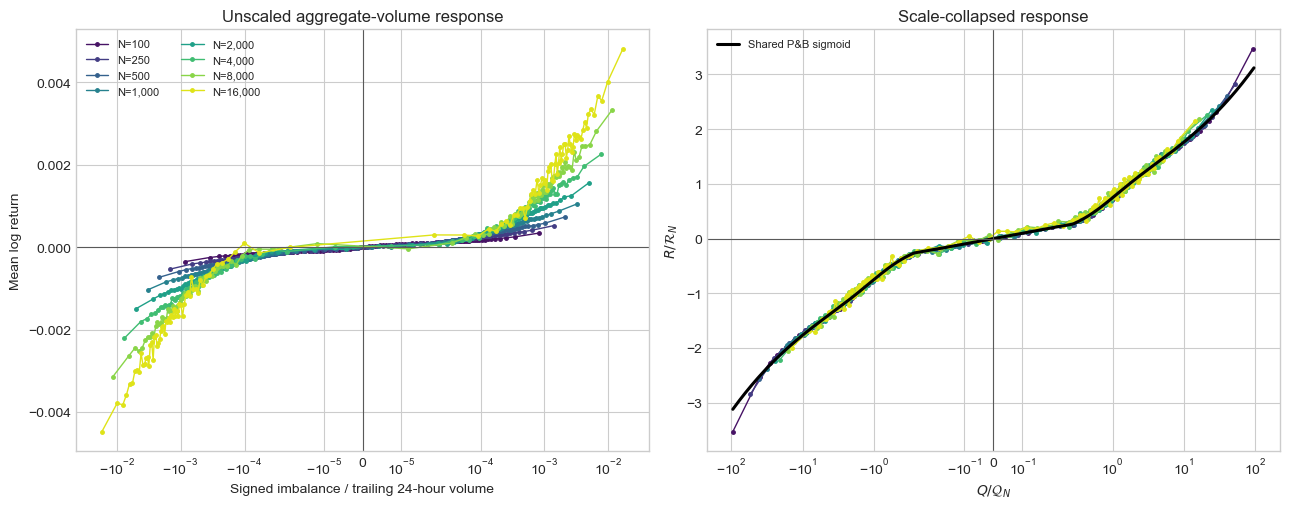

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
colours = plt.cm.viridis(np.linspace(0.05, 0.95, len(N_VALUES)))
for colour, n in zip(colours, N_VALUES):
    raw = volume_curves.loc[volume_curves['n_events'] == n]
    collapsed = collapsed_curves.loc[collapsed_curves['n_events'] == n]
    axes[0].plot(raw['mean_q'], raw['mean_response'], marker='o', ms=2.5, lw=1,
                 color=colour, label=f'N={n:,}')
    axes[1].plot(collapsed['scaled_q'], collapsed['scaled_response'], marker='o',
                 ms=2.5, lw=1, color=colour)
raw_linthresh = max(volume_curves['mean_q'].abs().quantile(0.10), 1e-12)
scaled_linthresh = max(collapsed_curves['scaled_q'].abs().quantile(0.10), 1e-12)
axes[0].set_xscale('symlog', linthresh=raw_linthresh)
axes[0].set_xlabel('Signed imbalance / trailing 24-hour volume')
axes[0].set_ylabel('Mean log return')
axes[0].set_title('Unscaled aggregate-volume response')
axes[0].legend(ncol=2, fontsize=8)
positive_grid = np.geomspace(
    max(collapsed_curves['scaled_q'].abs().min(), 1e-8),
    collapsed_curves['scaled_q'].abs().max(), 300,
)
grid = np.r_[-positive_grid[::-1], 0.0, positive_grid]
axes[1].plot(grid, pb_shape(grid, master_fit['alpha'], master_fit['beta']),
             color='black', lw=2.2, label='Shared P&B sigmoid')
axes[1].set_xscale('symlog', linthresh=scaled_linthresh)
axes[1].set_xlabel(r'$Q/\mathcal{Q}_N$')
axes[1].set_ylabel(r'$R/\mathcal{R}_N$')
axes[1].set_title('Scale-collapsed response')
for ax in axes:
    ax.axhline(0, color='0.35', lw=0.8)
    ax.axvline(0, color='0.35', lw=0.8)
axes[1].legend(fontsize=8)
fig.tight_layout()
collapse_figure = FIGURE_DIR / '22_pb_volume_impact_scaling_collapse.pdf'
fig.savefig(collapse_figure, bbox_inches='tight')
plt.show()

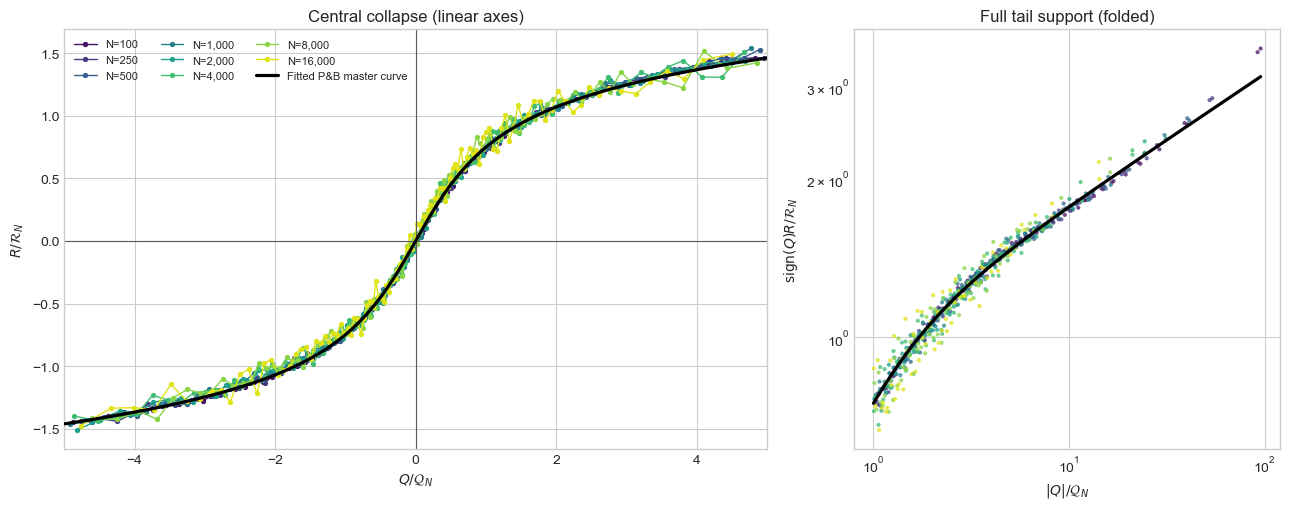

In [55]:
# Presentation view: linear central range plus full-support folded tails.
presentation_limit = 5.0
fig, (central_ax, tail_ax) = plt.subplots(
    1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [1.65, 1]}
)
for colour, n in zip(colours, N_VALUES):
    curve = collapsed_curves.loc[collapsed_curves['n_events'] == n].copy()
    central = curve.loc[curve['scaled_q'].abs() <= presentation_limit]
    central_ax.plot(
        central['scaled_q'], central['scaled_response'], marker='o', ms=2.8,
        lw=1, color=colour, label=f'N={n:,}', zorder=2,
    )
    tail_x = curve['scaled_q'].abs().to_numpy()
    tail_y = (
        np.sign(curve['scaled_q']) * curve['scaled_response']
    ).to_numpy()
    tail_mask = (tail_x >= 1.0) & (tail_y > 0)
    tail_ax.scatter(
        tail_x[tail_mask], tail_y[tail_mask], s=9, alpha=0.75,
        color=colour, edgecolors='none', zorder=2,
    )

central_grid = np.linspace(-presentation_limit, presentation_limit, 4001)
central_ax.plot(
    central_grid, pb_shape(central_grid, master_fit['alpha'], master_fit['beta']),
    color='black', lw=2.3, label='Fitted P&B master curve', zorder=3,
)
central_ax.axhline(0, color='0.35', lw=0.8)
central_ax.axvline(0, color='0.35', lw=0.8)
central_ax.set_xlim(-presentation_limit, presentation_limit)
central_ax.set_xlabel(r'$Q/\mathcal{Q}_N$')
central_ax.set_ylabel(r'$R/\mathcal{R}_N$')
central_ax.set_title('Central collapse (linear axes)')
central_ax.legend(ncol=3, fontsize=8)

tail_max = collapsed_curves['scaled_q'].abs().max()
tail_grid = np.geomspace(1.0, tail_max, 2000)
tail_ax.plot(
    tail_grid, pb_shape(tail_grid, master_fit['alpha'], master_fit['beta']),
    color='black', lw=2.3, zorder=3,
)
tail_ax.set_xscale('log')
tail_ax.set_yscale('log')
tail_ax.set_xlabel(r'$|Q|/\mathcal{Q}_N$')
tail_ax.set_ylabel(r'$\operatorname{sign}(Q)R/\mathcal{R}_N$')
tail_ax.set_title('Full tail support (folded)')
fig.tight_layout()
presentation_collapse_figure = (
    FIGURE_DIR / '22b_pb_volume_impact_scaling_collapse_presentation.pdf'
)
fig.savefig(presentation_collapse_figure, bbox_inches='tight')
plt.show()

## Scale exponents and block-sum Hurst exponents

The fitted curve scales are regressed on (N) in logs. Raw signed-volume,
order-sign and return Hurst exponents are estimated from non-overlapping block
sums, matching the variance-scaling definition used by P&B. The scaling of the
trailing-volume-normalised imbalance is reported separately: because its
denominator varies through time, it is not literally a block-sum Hurst exponent.
Theil--Sen
slopes are reported for resistance to individual scales; OLS slopes and
(R^2) are retained as diagnostics.

,quantity,column,robust_exponent,robust_lower_95,robust_upper_95,ols_exponent,ols_r_squared
0,xi: fitted response width,fitted_q_scale,0.954524,0.892727,1.002027,0.958761,0.996188
1,psi: fitted response height,fitted_r_scale,0.608060,0.596499,0.626061,0.612770,0.999252
2,"H_q,24h: trailing-normalised signed volume",trailing_volume_fraction_std,0.629415,0.615760,0.638856,0.627644,0.999842
3,"H_q,raw: signed BTC volume",signed_volume_std,0.628326,0.613649,0.638024,0.625570,0.999804
4,H_epsilon: order signs,sign_sum_std,0.763641,0.754425,0.769209,0.762560,0.999951
5,H_r: returns,return_std,0.507316,0.496585,0.513050,0.507810,0.999687


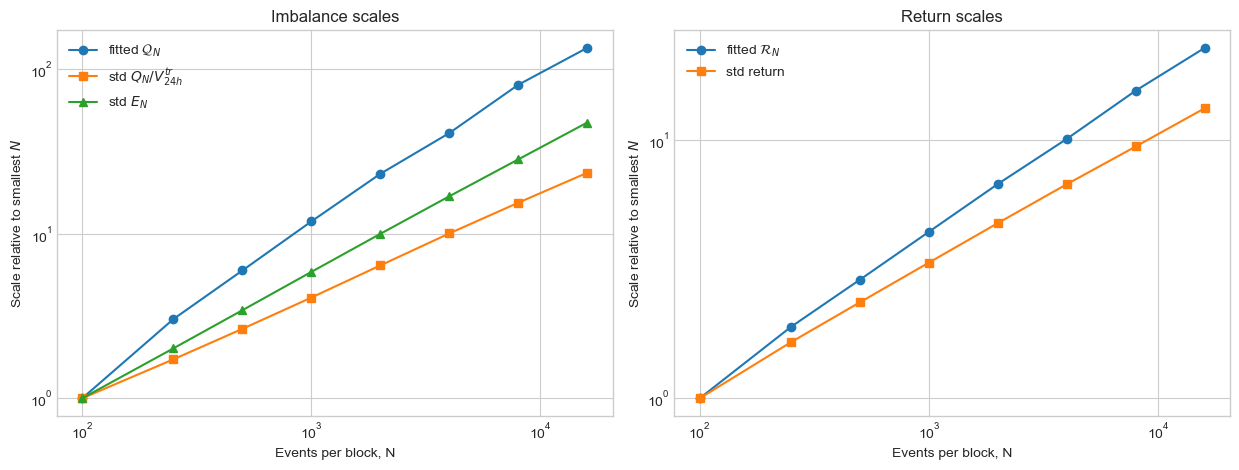

In [56]:
empirical_scale_rows = []
for n, data in blocks_by_n.items():
    empirical_scale_rows.append({
        'n_events': n,
        'trailing_volume_fraction_std': data['pb_signed_volume'].std(),
        'signed_volume_std': data['signed_volume_btc'].std(),
        'sign_sum_std': data['sign_sum'].std(),
        'return_std': data['log_return'].std(),
        'daily_adjusted_signed_volume_std': data['pb_daily_adjusted_signed_volume'].std(),
    })
empirical_scales = pd.DataFrame(empirical_scale_rows)
scale_estimates = master_fit['scales'].copy().merge(
    empirical_scales, on='n_events', validate='one_to_one'
)


def scaling_slope(table, value_column, label):
    x = np.log(table['n_events'].to_numpy(dtype=float))
    y = np.log(table[value_column].to_numpy(dtype=float))
    robust = theilslopes(y, x, 0.95)
    ordinary = linregress(x, y)
    return {
        'quantity': label, 'column': value_column,
        'robust_exponent': robust.slope,
        'robust_lower_95': robust.low_slope,
        'robust_upper_95': robust.high_slope,
        'ols_exponent': ordinary.slope,
        'ols_r_squared': ordinary.rvalue**2,
    }


exponent_table = pd.DataFrame([
    scaling_slope(scale_estimates, 'fitted_q_scale', 'xi: fitted response width'),
    scaling_slope(scale_estimates, 'fitted_r_scale', 'psi: fitted response height'),
    scaling_slope(scale_estimates, 'trailing_volume_fraction_std',
                  'H_q,24h: trailing-normalised signed volume'),
    scaling_slope(scale_estimates, 'signed_volume_std', 'H_q,raw: signed BTC volume'),
    scaling_slope(scale_estimates, 'sign_sum_std', 'H_epsilon: order signs'),
    scaling_slope(scale_estimates, 'return_std', 'H_r: returns'),
])
display(exponent_table)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
for column, label, marker in [
    ('fitted_q_scale', r'fitted $\mathcal{Q}_N$', 'o'),
    ('trailing_volume_fraction_std', r'std $Q_N/V^{tr}_{24h}$', 's'),
    ('sign_sum_std', r'std $E_N$', '^'),
]:
    relative_scale = scale_estimates[column] / scale_estimates[column].iloc[0]
    axes[0].loglog(scale_estimates['n_events'], relative_scale,
                   marker=marker, label=label)
for column, label, marker in [
    ('fitted_r_scale', r'fitted $\mathcal{R}_N$', 'o'),
    ('return_std', r'std return', 's'),
]:
    relative_scale = scale_estimates[column] / scale_estimates[column].iloc[0]
    axes[1].loglog(scale_estimates['n_events'], relative_scale,
                   marker=marker, label=label)
for ax, title in zip(axes, ['Imbalance scales', 'Return scales']):
    ax.set_xlabel('Events per block, N')
    ax.set_ylabel(r'Scale relative to smallest $N$')
    ax.set_title(title)
    ax.legend()
fig.tight_layout()
scale_figure = FIGURE_DIR / '23_pb_scale_and_hurst_exponents.pdf'
fig.savefig(scale_figure, bbox_inches='tight')
plt.show()

## Extreme imbalance and transaction-price pinning

P&B distinguish aggregate signed volume from two bounded measures of how
one-sided a window is: mean order sign (E_N/N) and signed volume divided by
gross volume (Q_N/V_N). The primary curves independently quantile-bin the
positive and negative halves and plot raw returns against signed imbalance. Folded
fixed-width curves are saved as secondary magnitude diagnostics. The price-change
fraction is only a transaction-price
proxy for their quote-midpoint statistic.

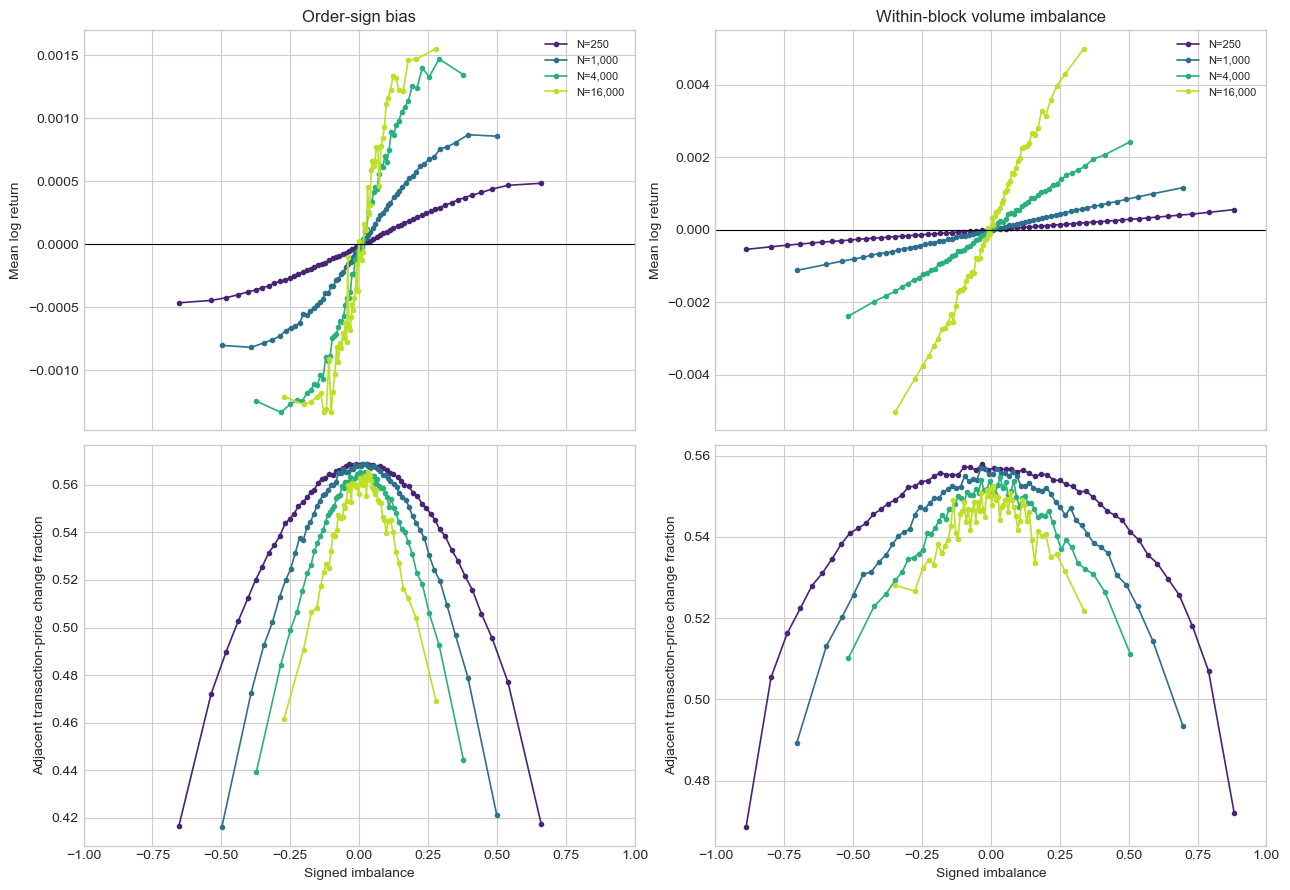

In [57]:
def independently_binned_signed_pinning_curve(
    data, variable, n_bins=PINNING_BINS, activity_group='all'
):
    columns = [variable, 'log_return', 'price_change_fraction', 'endpoint_price_changed']
    work = data[columns].dropna().copy()
    work = work.loc[work[variable] != 0]
    work['side'] = np.where(work[variable] < 0, 'negative', 'positive')
    work['abs_condition'] = work[variable].abs().clip(0, 1)
    curves = []
    for side, half in work.groupby('side', observed=True):
        half = half.copy()
        half['bin'] = pd.qcut(
            half['abs_condition'], q=n_bins, labels=False, duplicates='drop'
        )
        curve = half.groupby('bin', observed=True).agg(
            mean_condition=(variable, 'mean'),
            mean_response=('log_return', 'mean'),
            response_std=('log_return', 'std'),
            mean_price_change_fraction=('price_change_fraction', 'mean'),
            endpoint_move_probability=('endpoint_price_changed', 'mean'),
            observations=('log_return', 'size'),
        ).reset_index()
        curve.insert(0, 'side', side)
        curves.append(curve)
    curve = pd.concat(curves, ignore_index=True)
    curve['response_standard_error'] = curve['response_std'] / np.sqrt(curve['observations'])
    curve = curve.loc[curve['observations'] >= MIN_BIN_OBS].copy()
    curve.insert(0, 'activity_group', activity_group)
    curve.insert(0, 'conditioning_variable', variable)
    return curve.sort_values('mean_condition').reset_index(drop=True)


def folded_fixed_width_pinning_curve(
    data, variable, n_bins=PINNING_BINS, activity_group='all'
):
    columns = [variable, 'log_return', 'price_change_fraction', 'endpoint_price_changed']
    work = data[columns].dropna().copy()
    work['abs_condition'] = work[variable].abs().clip(0, 1)
    work['signed_response'] = np.sign(work[variable]) * work['log_return']
    edges = np.linspace(0, 1, n_bins + 1)
    work['bin'] = pd.cut(work['abs_condition'], edges, include_lowest=True, labels=False)
    curve = work.groupby('bin', observed=True).agg(
        mean_abs_condition=('abs_condition', 'mean'),
        mean_signed_response=('signed_response', 'mean'),
        response_std=('signed_response', 'std'),
        mean_price_change_fraction=('price_change_fraction', 'mean'),
        endpoint_move_probability=('endpoint_price_changed', 'mean'),
        observations=('signed_response', 'size'),
    ).reset_index()
    curve['response_standard_error'] = curve['response_std'] / np.sqrt(curve['observations'])
    curve = curve.loc[curve['observations'] >= MIN_BIN_OBS].copy()
    curve.insert(0, 'activity_group', activity_group)
    curve.insert(0, 'conditioning_variable', variable)
    return curve


selected_n = tuple(n for n in (250, 1000, 4000, 16000) if n in N_VALUES)
if not selected_n:
    selected_n = N_VALUES
signed_pinning_frames = []
folded_pinning_frames = []
for n in selected_n:
    for variable in ('sign_bias', 'trade_imbalance'):
        signed_curve = independently_binned_signed_pinning_curve(
            blocks_by_n[n], variable
        )
        signed_curve.insert(0, 'n_events', n)
        signed_pinning_frames.append(signed_curve)
        folded_curve = folded_fixed_width_pinning_curve(blocks_by_n[n], variable)
        folded_curve.insert(0, 'n_events', n)
        folded_pinning_frames.append(folded_curve)
signed_pinning_curves = pd.concat(signed_pinning_frames, ignore_index=True)
folded_pinning_curves = pd.concat(folded_pinning_frames, ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex='col')
variable_titles = {'sign_bias': 'Order-sign bias', 'trade_imbalance': 'Within-block volume imbalance'}
for column, variable in enumerate(('sign_bias', 'trade_imbalance')):
    for colour, n in zip(plt.cm.viridis(np.linspace(.1, .9, len(selected_n))), selected_n):
        curve = signed_pinning_curves.loc[
            (signed_pinning_curves['n_events'] == n)
            & (signed_pinning_curves['conditioning_variable'] == variable)
        ]
        axes[0, column].plot(curve['mean_condition'], curve['mean_response'],
                             marker='o', ms=3, lw=1.2, color=colour, label=f'N={n:,}')
        axes[1, column].plot(curve['mean_condition'],
                             curve['mean_price_change_fraction'], marker='o', ms=3,
                             lw=1.2, color=colour)
    axes[0, column].set_title(variable_titles[variable])
    axes[0, column].set_ylabel('Mean log return')
    axes[1, column].set_ylabel('Adjacent transaction-price change fraction')
    axes[1, column].set_xlabel('Signed imbalance')
    axes[1, column].set_xlim(-1, 1)
    axes[0, column].axhline(0, color='black', lw=.8)
    axes[0, column].legend(fontsize=8)
fig.tight_layout()
pinning_figure = FIGURE_DIR / '24_pb_transaction_price_pinning.pdf'
fig.savefig(pinning_figure, bbox_inches='tight')
plt.show()

## Does activity reconcile pinning with the high-imbalance tail?

The pooled P&B diagnostic is now split at each (N) into the lowest and highest
event-intensity quintiles. A separate state table cross-classifies activity and
absolute trailing-volume-normalised signed BTC imbalance. This determines whether the paper's
high/high observations are also nearly unidirectional in sign or volume ratio.

,n_events,activity_state,imbalance_state,observations,mean_signed_response,mean_master_residual,master_residual_standard_error,mean_scaled_master_residual,scaled_master_residual_standard_error,mean_abs_sign_bias,mean_abs_trade_imbalance,mean_price_change_fraction,median_event_intensity
0,250,ordinary_activity,ordinary_imbalance,1195558,0.000161,-0.000010,0.000000,-0.055168,0.001409,0.209507,0.298549,0.543649,10.691528
1,250,ordinary_activity,extreme_imbalance,272224,0.000324,-0.000021,0.000001,-0.113544,0.002941,0.279250,0.636896,0.503772,11.051678
2,250,high_activity,ordinary_imbalance,272187,0.000218,0.000048,0.000001,0.259263,0.004531,0.206239,0.285583,0.588079,55.506217
3,250,high_activity,extreme_imbalance,94712,0.000426,0.000063,0.000002,0.338842,0.008933,0.284795,0.615704,0.524975,65.685759
4,1000,ordinary_activity,ordinary_imbalance,298876,0.000330,-0.000028,0.000001,-0.064321,0.002440,0.150998,0.201930,0.542802,10.380982
5,1000,ordinary_activity,extreme_imbalance,68060,0.000680,-0.000055,0.000002,-0.127489,0.005154,0.201342,0.475361,0.502569,10.816365
6,1000,high_activity,ordinary_imbalance,68059,0.000476,0.000120,0.000003,0.274939,0.007894,0.151150,0.205359,0.591330,50.553561
7,1000,high_activity,extreme_imbalance,23674,0.000934,0.000169,0.000006,0.388540,0.013135,0.202515,0.475593,0.529769,58.651027
8,4000,ordinary_activity,ordinary_imbalance,74494,0.000677,-0.000078,0.000004,-0.078751,0.004104,0.108328,0.135942,0.540984,10.187579
9,4000,ordinary_activity,extreme_imbalance,17239,0.001425,-0.000144,0.000009,-0.144646,0.008608,0.134902,0.332959,0.504330,10.423235


,n_events,high_activity_extreme_scaled_residual,activity_imbalance_interaction
0,250,0.338842,0.137955
1,1000,0.388540,0.176769
2,4000,0.504842,0.220825
3,16000,0.625016,0.306198


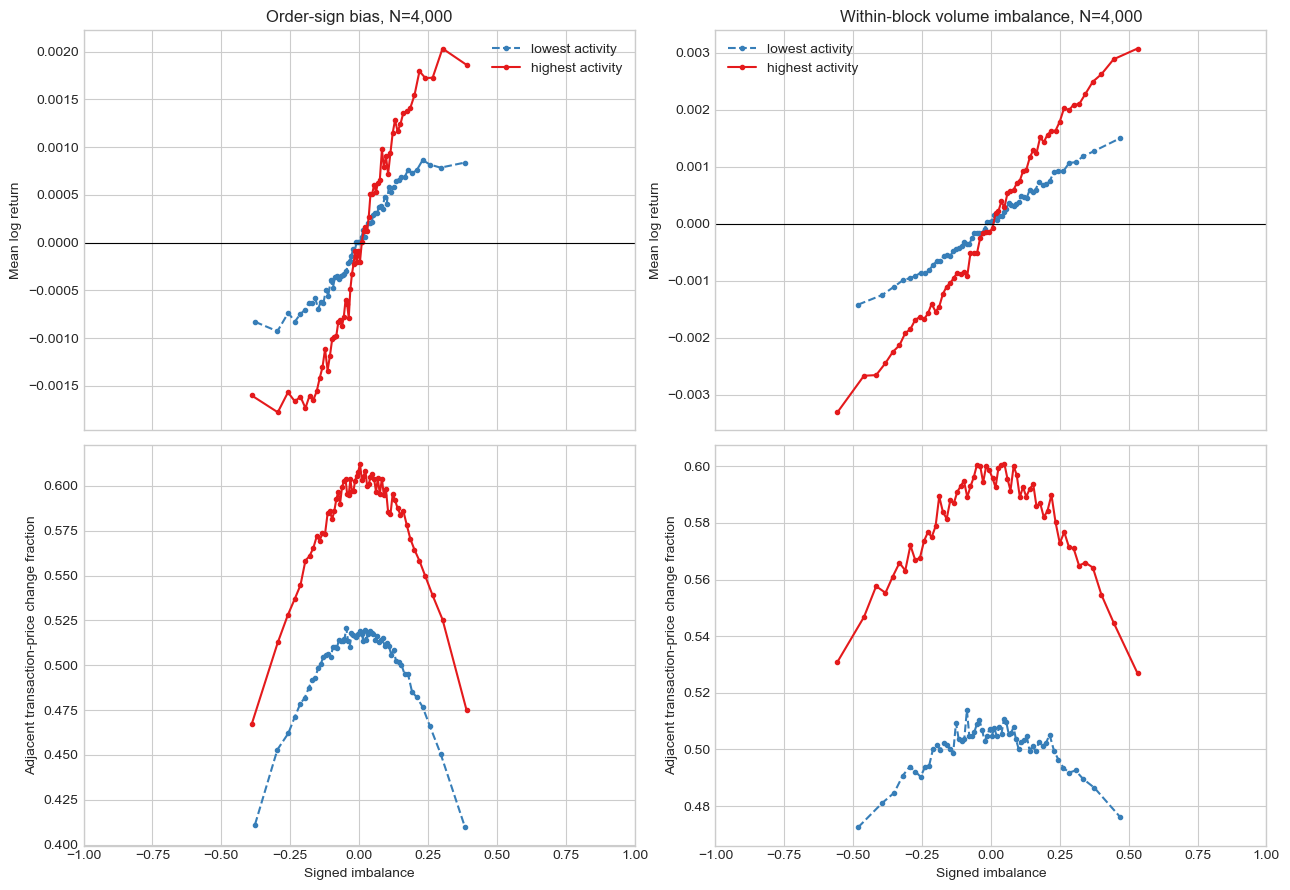

In [58]:
activity_signed_pinning_frames = []
activity_folded_pinning_frames = []
state_rows = []
for n in selected_n:
    data = blocks_by_n[n].dropna(subset=['event_intensity', 'pb_signed_volume']).copy()
    q_scale = scale_lookup.loc[n, 'fitted_q_scale']
    r_scale = scale_lookup.loc[n, 'fitted_r_scale']
    data['signed_response'] = (
        np.sign(data['pb_signed_volume']) * data['log_return']
    )
    data['master_prediction'] = r_scale * pb_shape(
        data['pb_signed_volume'].abs() / q_scale,
        master_fit['alpha'], master_fit['beta'],
    )
    data['master_residual'] = (
        data['signed_response'] - data['master_prediction']
    )
    data['scaled_master_residual'] = data['master_residual'] / r_scale
    data['activity_quintile'] = pd.qcut(
        data['event_intensity'], 5, labels=False, duplicates='drop'
    )
    data['q_quintile'] = pd.qcut(
        data['pb_signed_volume'].abs(), 5, labels=False, duplicates='drop'
    )
    highest_activity = data['activity_quintile'].max()
    for activity_group, subset in [
        ('lowest activity', data.loc[data['activity_quintile'] == 0]),
        ('highest activity', data.loc[data['activity_quintile'] == highest_activity]),
    ]:
        for variable in ('sign_bias', 'trade_imbalance'):
            signed_curve = independently_binned_signed_pinning_curve(
                subset, variable, activity_group=activity_group
            )
            signed_curve.insert(0, 'n_events', n)
            activity_signed_pinning_frames.append(signed_curve)
            folded_curve = folded_fixed_width_pinning_curve(
                subset, variable, activity_group=activity_group
            )
            folded_curve.insert(0, 'n_events', n)
            activity_folded_pinning_frames.append(folded_curve)
    for activity_label, activity_test in [
        ('ordinary_activity', data['activity_quintile'] < highest_activity),
        ('high_activity', data['activity_quintile'] == highest_activity),
    ]:
        for q_label, q_test in [
            ('ordinary_imbalance', data['q_quintile'] < data['q_quintile'].max()),
            ('extreme_imbalance', data['q_quintile'] == data['q_quintile'].max()),
        ]:
            group = data.loc[activity_test & q_test].copy()
            direction = np.sign(group['pb_signed_volume'])
            residual_standard_error = (
                group['master_residual'].std() / np.sqrt(len(group))
            )
            state_rows.append({
                'n_events': n, 'activity_state': activity_label,
                'imbalance_state': q_label, 'observations': len(group),
                'mean_signed_response': (direction * group['log_return']).mean(),
                'mean_master_residual': group['master_residual'].mean(),
                'master_residual_standard_error': residual_standard_error,
                'mean_scaled_master_residual': group['scaled_master_residual'].mean(),
                'scaled_master_residual_standard_error': residual_standard_error / r_scale,
                'mean_abs_sign_bias': group['sign_bias'].abs().mean(),
                'mean_abs_trade_imbalance': group['trade_imbalance'].abs().mean(),
                'mean_price_change_fraction': group['price_change_fraction'].mean(),
                'median_event_intensity': group['event_intensity'].median(),
            })
activity_signed_pinning_curves = pd.concat(
    activity_signed_pinning_frames, ignore_index=True
)
activity_folded_pinning_curves = pd.concat(
    activity_folded_pinning_frames, ignore_index=True
)
activity_state_summary = pd.DataFrame(state_rows)
display(activity_state_summary)
interaction_rows = []
for n, group in activity_state_summary.groupby('n_events', observed=True):
    values = group.set_index(['activity_state', 'imbalance_state'])[
        'mean_scaled_master_residual'
    ]
    high_extreme = values.loc[('high_activity', 'extreme_imbalance')]
    high_ordinary = values.loc[('high_activity', 'ordinary_imbalance')]
    ordinary_extreme = values.loc[('ordinary_activity', 'extreme_imbalance')]
    ordinary_ordinary = values.loc[('ordinary_activity', 'ordinary_imbalance')]
    interaction_rows.append({
        'n_events': n,
        'high_activity_extreme_scaled_residual': high_extreme,
        'activity_imbalance_interaction': (
            (high_extreme - high_ordinary)
            - (ordinary_extreme - ordinary_ordinary)
        ),
    })
activity_interaction_summary = pd.DataFrame(interaction_rows)
display(activity_interaction_summary)

comparison_n = 4000 if 4000 in selected_n else selected_n[len(selected_n) // 2]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex='col')
styles = {'lowest activity': ('#377eb8', '--'), 'highest activity': ('#e41a1c', '-') }
for column, variable in enumerate(('sign_bias', 'trade_imbalance')):
    for activity_group, (colour, linestyle) in styles.items():
        curve = activity_signed_pinning_curves.loc[
            (activity_signed_pinning_curves['n_events'] == comparison_n)
            & (activity_signed_pinning_curves['conditioning_variable'] == variable)
            & (activity_signed_pinning_curves['activity_group'] == activity_group)
        ]
        axes[0, column].plot(curve['mean_condition'], curve['mean_response'],
                             marker='o', ms=3, lw=1.5, ls=linestyle, color=colour,
                             label=activity_group)
        axes[1, column].plot(curve['mean_condition'],
                             curve['mean_price_change_fraction'], marker='o', ms=3,
                             lw=1.5, ls=linestyle, color=colour)
    axes[0, column].set_title(variable_titles[variable] + f', N={comparison_n:,}')
    axes[0, column].set_ylabel('Mean log return')
    axes[1, column].set_ylabel('Adjacent transaction-price change fraction')
    axes[1, column].set_xlabel('Signed imbalance')
    axes[1, column].set_xlim(-1, 1)
    axes[0, column].axhline(0, color='black', lw=.8)
    axes[0, column].legend()
fig.tight_layout()
activity_figure = FIGURE_DIR / '25_pb_pinning_by_activity.pdf'
fig.savefig(activity_figure, bbox_inches='tight')
plt.show()

## Interpretation checklist

1. A visually successful collapse is not sufficient: inspect the collapse
   residuals and the stability of the shared shape parameters.
2. P&B pinning is strongest for order-sign bias and bounded trade imbalance; do
   not equate either mechanically with trailing-volume-normalised signed BTC imbalance.
3. If pooled pinning is reproduced but weakens in the highest-activity quintile,
   the results are complementary: activity identifies a departure from the pooled
   master curve.
4. If transaction-price change probability rises at extreme imbalance, this does
   not by itself refute quote-midpoint pinning because bid--ask bounce is present.
5. Signed curves are the primary replication result. Folded curves improve precision
   under antisymmetry, but must not be used to assess buy--sell asymmetry.

In [59]:
master_parameters = pd.DataFrame([{
    'volume_metric': 'signed_volume_over_trailing_24h_volume',
    'alpha': master_fit['alpha'], 'beta': master_fit['beta'],
    'robust_objective': master_fit['objective'],
    'converged': master_fit['result'].success,
    'message': master_fit['result'].message,
}])
collapse_summary = collapsed_curves.groupby('n_events', observed=True).agg(
    collapse_rmse=('collapse_residual', lambda x: np.sqrt(np.mean(np.square(x)))),
    collapse_mae=('collapse_residual', lambda x: np.mean(np.abs(x))),
    bins=('collapse_residual', 'size'),
).reset_index()

outputs = {
    'pb_block_sample_summary.csv': sample_summary,
    'pb_volume_response_curves.csv': volume_curves,
    'pb_folded_volume_response_curves.csv': folded_volume_curves,
    'pb_master_curve_parameters.csv': master_parameters,
    'pb_volume_metric_sensitivity.csv': volume_metric_sensitivity,
    'pb_scale_estimates.csv': scale_estimates,
    'pb_scaling_exponents.csv': exponent_table,
    'pb_collapsed_volume_curves.csv': collapsed_curves,
    'pb_collapse_diagnostics.csv': collapse_summary,
    'pb_pinning_curves.csv': signed_pinning_curves,
    'pb_folded_pinning_curves.csv': folded_pinning_curves,
    'pb_activity_pinning_curves.csv': activity_signed_pinning_curves,
    'pb_activity_folded_pinning_curves.csv': activity_folded_pinning_curves,
    'pb_activity_state_summary.csv': activity_state_summary,
    'pb_activity_interaction_summary.csv': activity_interaction_summary,
}
for filename, table in outputs.items():
    table.to_csv(TABLE_DIR / filename, index=False)
print(f'Saved {len(outputs)} tables to {TABLE_DIR}')
print('Figures:')
for path in (collapse_figure, scale_figure, pinning_figure, activity_figure):
    print(' ', path)

Saved 15 tables to /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/tables
Figures:
  /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/22_pb_volume_impact_scaling_collapse.pdf
  /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/23_pb_scale_and_hurst_exponents.pdf
  /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/24_pb_transaction_price_pinning.pdf
  /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/25_pb_pinning_by_activity.pdf
